Importar dataset y librerias

In [33]:
import pandas as pd

#Import the dataset
dataset = 'CTC_processed.csv' #Lorca_original.csv para el de Lorca, Murcia
                               #CTC.csv para el de Santander, Cantabria
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

data.head(10)

,Power_gen,temperature,windSpeed,solarRad,humedad,rain,pressure,month,day,hour,minute
0,65,17.6,24.1,100.0,55.0,0.0,29.9,1,24,13,10
1,70,17.6,22.5,105.0,54.0,0.0,29.9,1,24,13,15
2,82,17.7,17.7,114.0,53.0,0.0,29.9,1,24,13,25
3,78,17.7,27.4,105.0,53.0,0.0,29.9,1,24,13,30
4,69,17.9,27.4,97.0,52.0,0.0,29.9,1,24,13,35
5,61,17.9,29.0,93.0,51.0,0.0,29.9,1,24,13,40
6,70,18.1,14.5,105.0,51.0,0.0,29.9,1,24,13,50
7,71,18.1,29.0,105.0,51.0,0.0,29.9,1,24,13,55
8,68,18.1,22.5,104.0,51.0,0.0,29.9,1,24,14,0
9,60,18.1,17.7,97.0,52.0,0.0,29.9,1,24,14,10


Separamos las variables predictoras y la variable objetivo. Preparamos el tratamiento de los valores=0

In [34]:
#Eliminamos filas con valores NaN antes de dividir en train y test
df_clean = data.dropna(subset=['Power_gen'])
predictors = df_clean.drop(columns=['Power_gen'])
objective = df_clean['Power_gen']

Dividimos los datos en train y test

In [35]:
#Dividimos los datos en train y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(predictors, objective, test_size=0.2, random_state=42) #20% para test

Calculamos los parámetros óptimos del modelo

In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

params = {'max_depth': [2, 5, 9], #profundidad maxima del arbol
          'learning_rate': [0.01, 0.1, 0.2], #tasa de aprendizaje
          'n_estimators': [50, 100, 900], #numero de arboles
          'subsample': [0.6, 0.8, 1.0]} #datos para entrenamiento de cada arbol
pruebas = XGBRegressor()
grid = GridSearchCV(pruebas, params, scoring='neg_root_mean_squared_error', cv=2, verbose=2) #calculamos el valor optimo de los parametros
grid.fit(X_train, y_train)
print(grid.best_params_)


Fitting 2 folds for each of 81 candidates, totalling 162 fits
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=50, subsample=1.0; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.6; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END learning_rate=0.01, max_depth=2, n_estimators=100, subsample=0.8; total time=   0.0s
[CV]

Creamos el modelo y entrenamos. Controlamos el sobreajuste.

In [37]:
from xgboost import XGBRegressor
xgb = XGBRegressor(learning_rate = 0.01, max_depth = 9, n_estimators = 900, subsample = 0.6) #aplicamos los parametros optimos obtenidos
xgb.fit(X_train, y_train)  #entrenamos el modelo

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=900,
             n_jobs=None, num_parallel_tree=None, ...)

Predicción y análisis

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("MAE: ", mean_absolute_error(y_test, y_pred)) #MAE = Error medio en la prediccion
print("MSE:", mse) #MSE = Error cuadratico medio en la prediccion
print("RMSE:", np.sqrt(mse)) #RMSE = Raiz del error cuadratico medio en la prediccion
print("R²:", r2_score(y_test, y_pred)) #R^2 = Coeficiente de determinacion

MAE:  30.618059158325195
MSE: 4562.69091796875
RMSE: 67.54769365395646
R²: 0.926432192325592


Obtener variables más importantes en la predicción

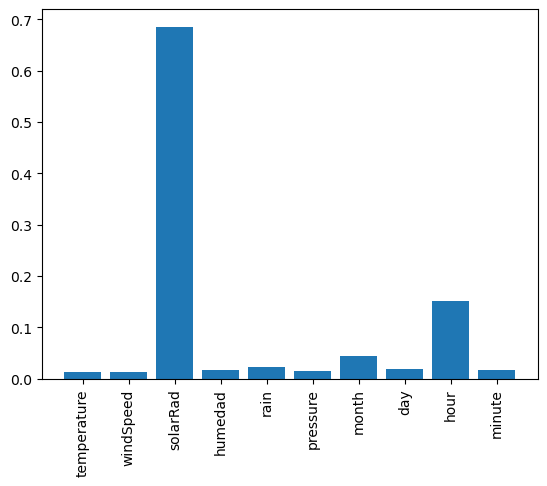

In [41]:
import matplotlib.pyplot as plt
plt.bar(X_train.columns, xgb.feature_importances_)
plt.xticks(rotation=90)
plt.show()


Comparativa predicción vs realidad

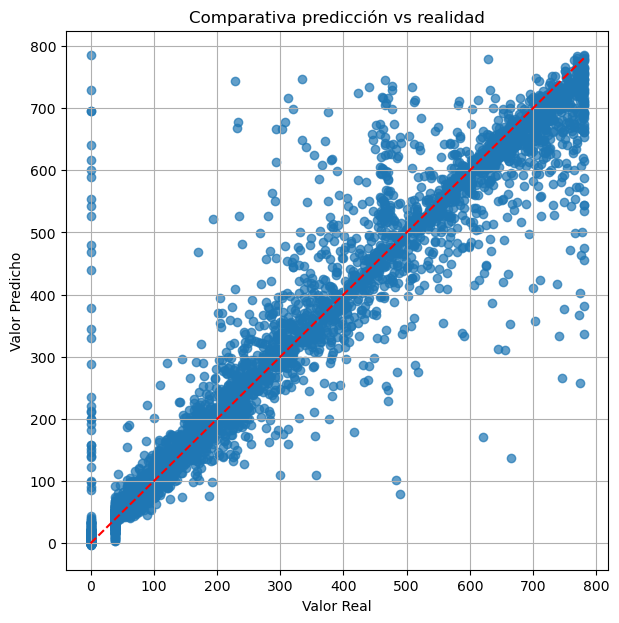

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()
